imports

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

state schema

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    final_result: int

build nodes

In [4]:
# this is the router node that will route the flow based on the operation
def router_node(state: AgentState) -> AgentState:
    """To route the flow based on the operation."""
    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "*":
        return "multiplication_operation"


# this is the addition operation node that will add two numbers
def adder(state: AgentState) -> AgentState:
    """To add two numbers."""
    state["final_result"] = state["number1"] + state["number2"]
    return state


# this is the multiplication operation node that will multiply two numbers
def multiplier(state: AgentState) -> AgentState:
    """To multiply two numbers."""
    state["final_result"] = state["number1"] * state["number2"]
    return state

create graph structure

In [5]:
graph = StateGraph(AgentState)

graph.add_node("router_node", lambda state: state)  # add a passthrough function for the router node | so state is passed forward as it is
graph.add_node("add_node", adder)  # add the addition operation node to the graph
graph.add_node("mul_node", multiplier)  # add the multiplication operation node to the

graph.add_edge(START, "router_node")  # add an edge from the start node to the router node
graph.add_conditional_edges(
    "router_node",
    router_node,
    {
        # Edge: node
        "addition_operation": "add_node",
        "multiplication_operation": "mul_node"
    }
)

graph.add_edge("add_node", END)  # add an edge from the addition operation node to the end node
graph.add_edge("mul_node", END)  # add an edge from the multiplication operation node

app = graph.compile()  # compile the graph into an executable app

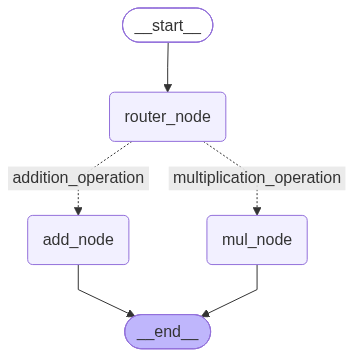

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

invoke graph

In [7]:
input = AgentState(number1=5, operation="+", number2=10, final_result=0)  # create an initial state for the graph
ans = app.invoke(input)  # invoke the graph with the initial state

In [10]:
input = AgentState(number1=5, operation="*", number2=10, final_result=0)  # create an initial state for the graph
ans = app.invoke(input)  # invoke the graph with the initial state

In [11]:
ans

{'number1': 5, 'operation': '*', 'number2': 10, 'final_result': 50}

In [12]:
ans['final_result']  # print the final state after the graph execution

50